# 对抗性训练实验结果可视化
生成多种精美的图表，白底黑字风格

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
import matplotlib.patches as mpatches

# 设置白底黑字风格
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    'text.color': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'grid.color': 'lightgray',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'figure.dpi': 150,
})

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 数据定义
models = ['Occlusion-AT', 'PGD-AT', 'FGSM-AT', 'Mix-AT']
metrics = ['Clean', 'FGSM', 'PGD', 'CW', 'Occlusion']

results = {
    'Occlusion-AT': {'Clean': 95.75, 'FGSM': 3.24, 'PGD': 0.00, 'CW': 0.00, 'Occlusion': 97.34},
    'PGD-AT': {'Clean': 99.30, 'FGSM': 96.10, 'PGD': 94.97, 'CW': 95.01, 'Occlusion': 49.17},
    'FGSM-AT': {'Clean': 99.20, 'FGSM': 95.68, 'PGD': 90.67, 'CW': 90.91, 'Occlusion': 54.14},
    'Mix-AT': {'Clean': 98.53, 'FGSM': 93.50, 'PGD': 91.71, 'CW': 91.69, 'Occlusion': 84.43},
}

# 白盒 vs 迁移攻击对比
transfer_results = {
    'Occlusion-AT': {
        'whitebox': {'FGSM': 3.24, 'PGD': 0.00, 'CW': 0.00, 'Occlusion': 97.34},
        'transfer': {'FGSM': 88.13, 'PGD': 89.67, 'CW': 91.79, 'Occlusion': 94.77}
    },
    'Mix-AT': {
        'whitebox': {'FGSM': 93.50, 'PGD': 91.75, 'CW': 91.67, 'Occlusion': 84.43},
        'transfer': {'FGSM': 97.40, 'PGD': 97.44, 'CW': 98.15, 'Occlusion': 88.49}
    }
}

# AutoAttack 结果
autoattack_results = {
    'Occlusion-AT': 0.00,
    'PGD-AT': 94.97,
    'FGSM-AT': 90.67,
    'Mix-AT': 90.91,
}

# Occlusion-AT 训练过程数据
occlusion_at_epochs = list(range(50))
occlusion_at_train_acc = [60.94, 79.80, 84.98, 88.36, 90.42, 91.91, 93.09, 93.90, 94.39, 94.91,
                          95.46, 95.67, 96.07, 96.16, 96.52, 96.35, 96.77, 96.90, 96.93, 97.12,
                          97.33, 97.33, 97.49, 97.53, 97.56, 97.67, 97.79, 97.92, 97.85, 98.04,
                          98.00, 98.11, 98.18, 97.99, 98.16, 98.13, 98.20, 98.17, 98.15, 98.31,
                          98.31, 98.31, 98.32, 98.37, 98.33, 98.35, 98.35, 98.44, 98.44, 98.55]
occlusion_at_test_acc = [75.70, 82.89, 87.63, 89.02, 91.56, 92.13, 93.34, 93.84, 94.37, 94.91,
                         95.10, 95.67, 95.82, 96.20, 96.05, 95.99, 96.54, 96.08, 96.77, 96.40,
                         96.75, 96.59, 96.93, 96.43, 96.87, 97.02, 97.17, 97.02, 97.05, 97.23,
                         97.26, 97.51, 97.26, 97.28, 97.29, 97.37, 96.92, 97.30, 97.42, 97.67,
                         97.51, 97.10, 96.91, 97.44, 97.34, 97.25, 97.09, 97.42, 97.58, 97.34]

# Mix-AT 训练过程数据
mix_at_epochs = list(range(10))
mix_at_train_acc = [62.60, 78.82, 82.18, 83.87, 85.01, 85.91, 86.64, 87.09, 87.90, 88.22]
mix_at_test_acc = [75.27, 81.28, 83.92, 84.77, 86.10, 86.35, 86.28, 87.29, 87.52, 88.22]
mix_at_train_clean = [95.05, 96.40, 97.14, 97.50, 97.71, 97.83, 98.31, 98.02, 98.32, 98.62]
mix_at_test_clean = [95.43, 96.45, 97.27, 97.49, 97.81, 97.84, 98.36, 98.00, 98.32, 98.53]

# 颜色方案
colors = {
    'Occlusion-AT': '#E74C3C',
    'PGD-AT': '#3498DB',
    'FGSM-AT': '#2ECC71',
    'Mix-AT': '#9B59B6',
}

attack_colors = {
    'Clean': '#3498DB',
    'FGSM': '#E74C3C',
    'PGD': '#E67E22',
    'CW': '#9B59B6',
    'Occlusion': '#1ABC9C',
}

import os
os.makedirs('./results_figures', exist_ok=True)

## 图1: 分组柱状图 - 四类模型的攻击准确率对比

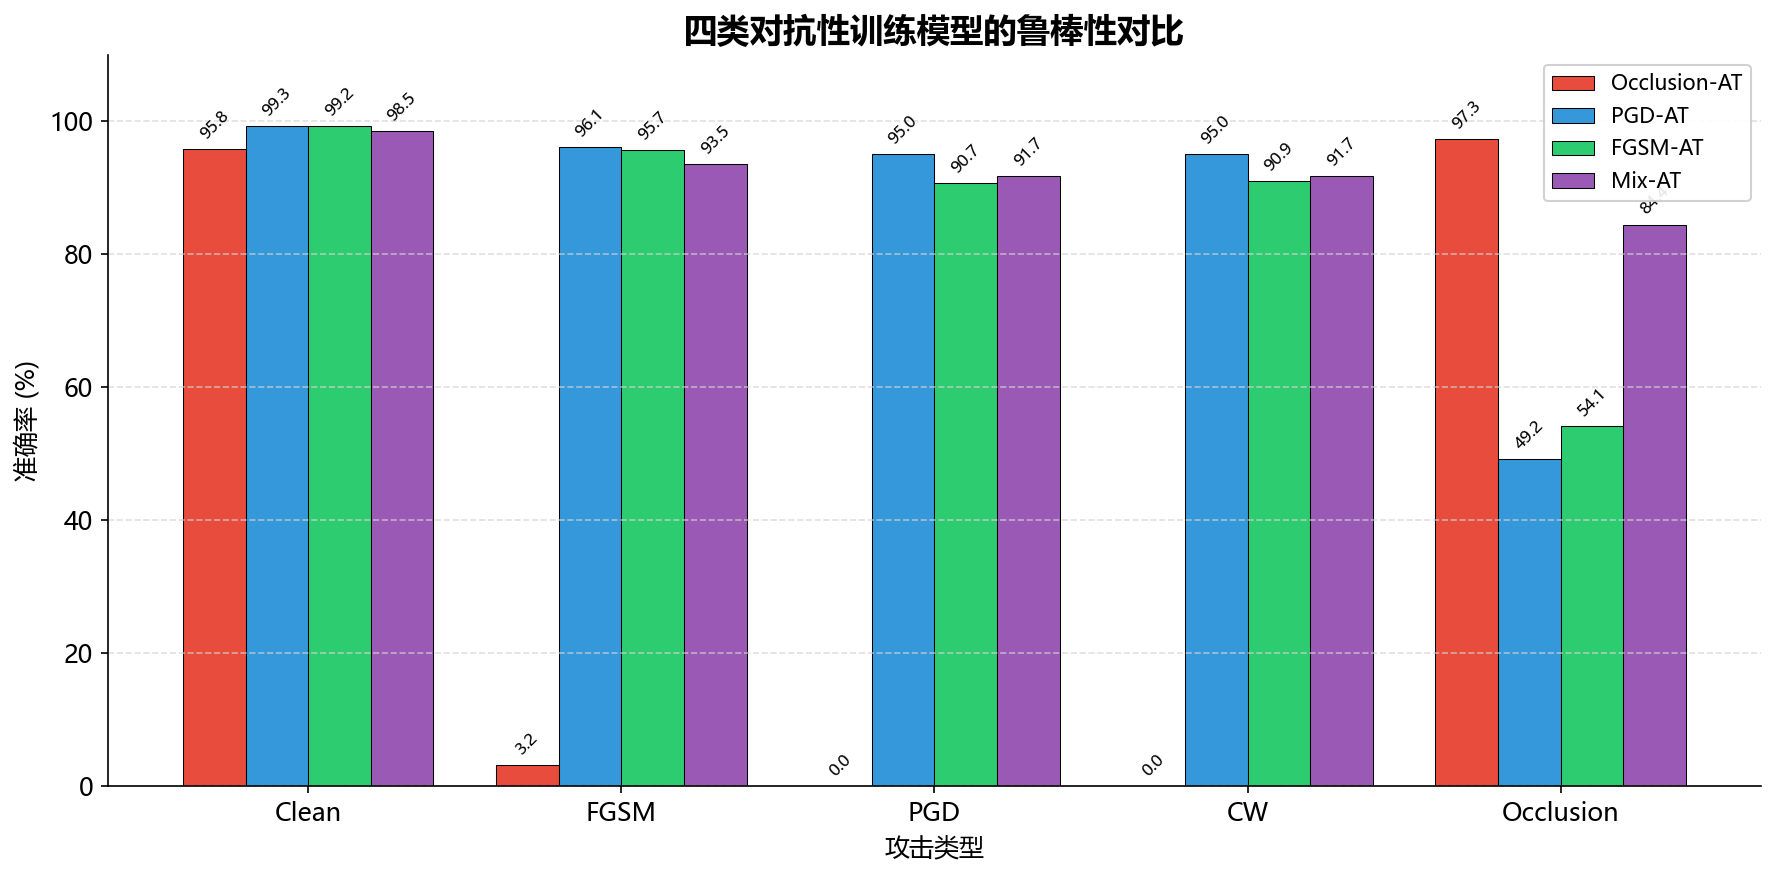

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(metrics))
width = 0.2

for i, model in enumerate(models):
    values = [results[model][m] for m in metrics]
    bars = ax.bar(x + i * width, values, width, label=model,
                  color=colors[model], edgecolor='black', linewidth=0.5)
    
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.annotate(f'{val:.1f}',
                   xy=(bar.get_x() + bar.get_width() / 2, height),
                   xytext=(0, 3),
                   textcoords="offset points",
                   ha='center', va='bottom', fontsize=8, rotation=45)

ax.set_ylabel('准确率 (%)')
ax.set_xlabel('攻击类型')
ax.set_title('四类对抗性训练模型的鲁棒性对比', fontsize=16, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.legend(loc='upper right', framealpha=0.9)
ax.set_ylim(0, 110)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('./results_figures/fig1_main_results_bar.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

## 图2: 雷达图 - 多维度性能对比

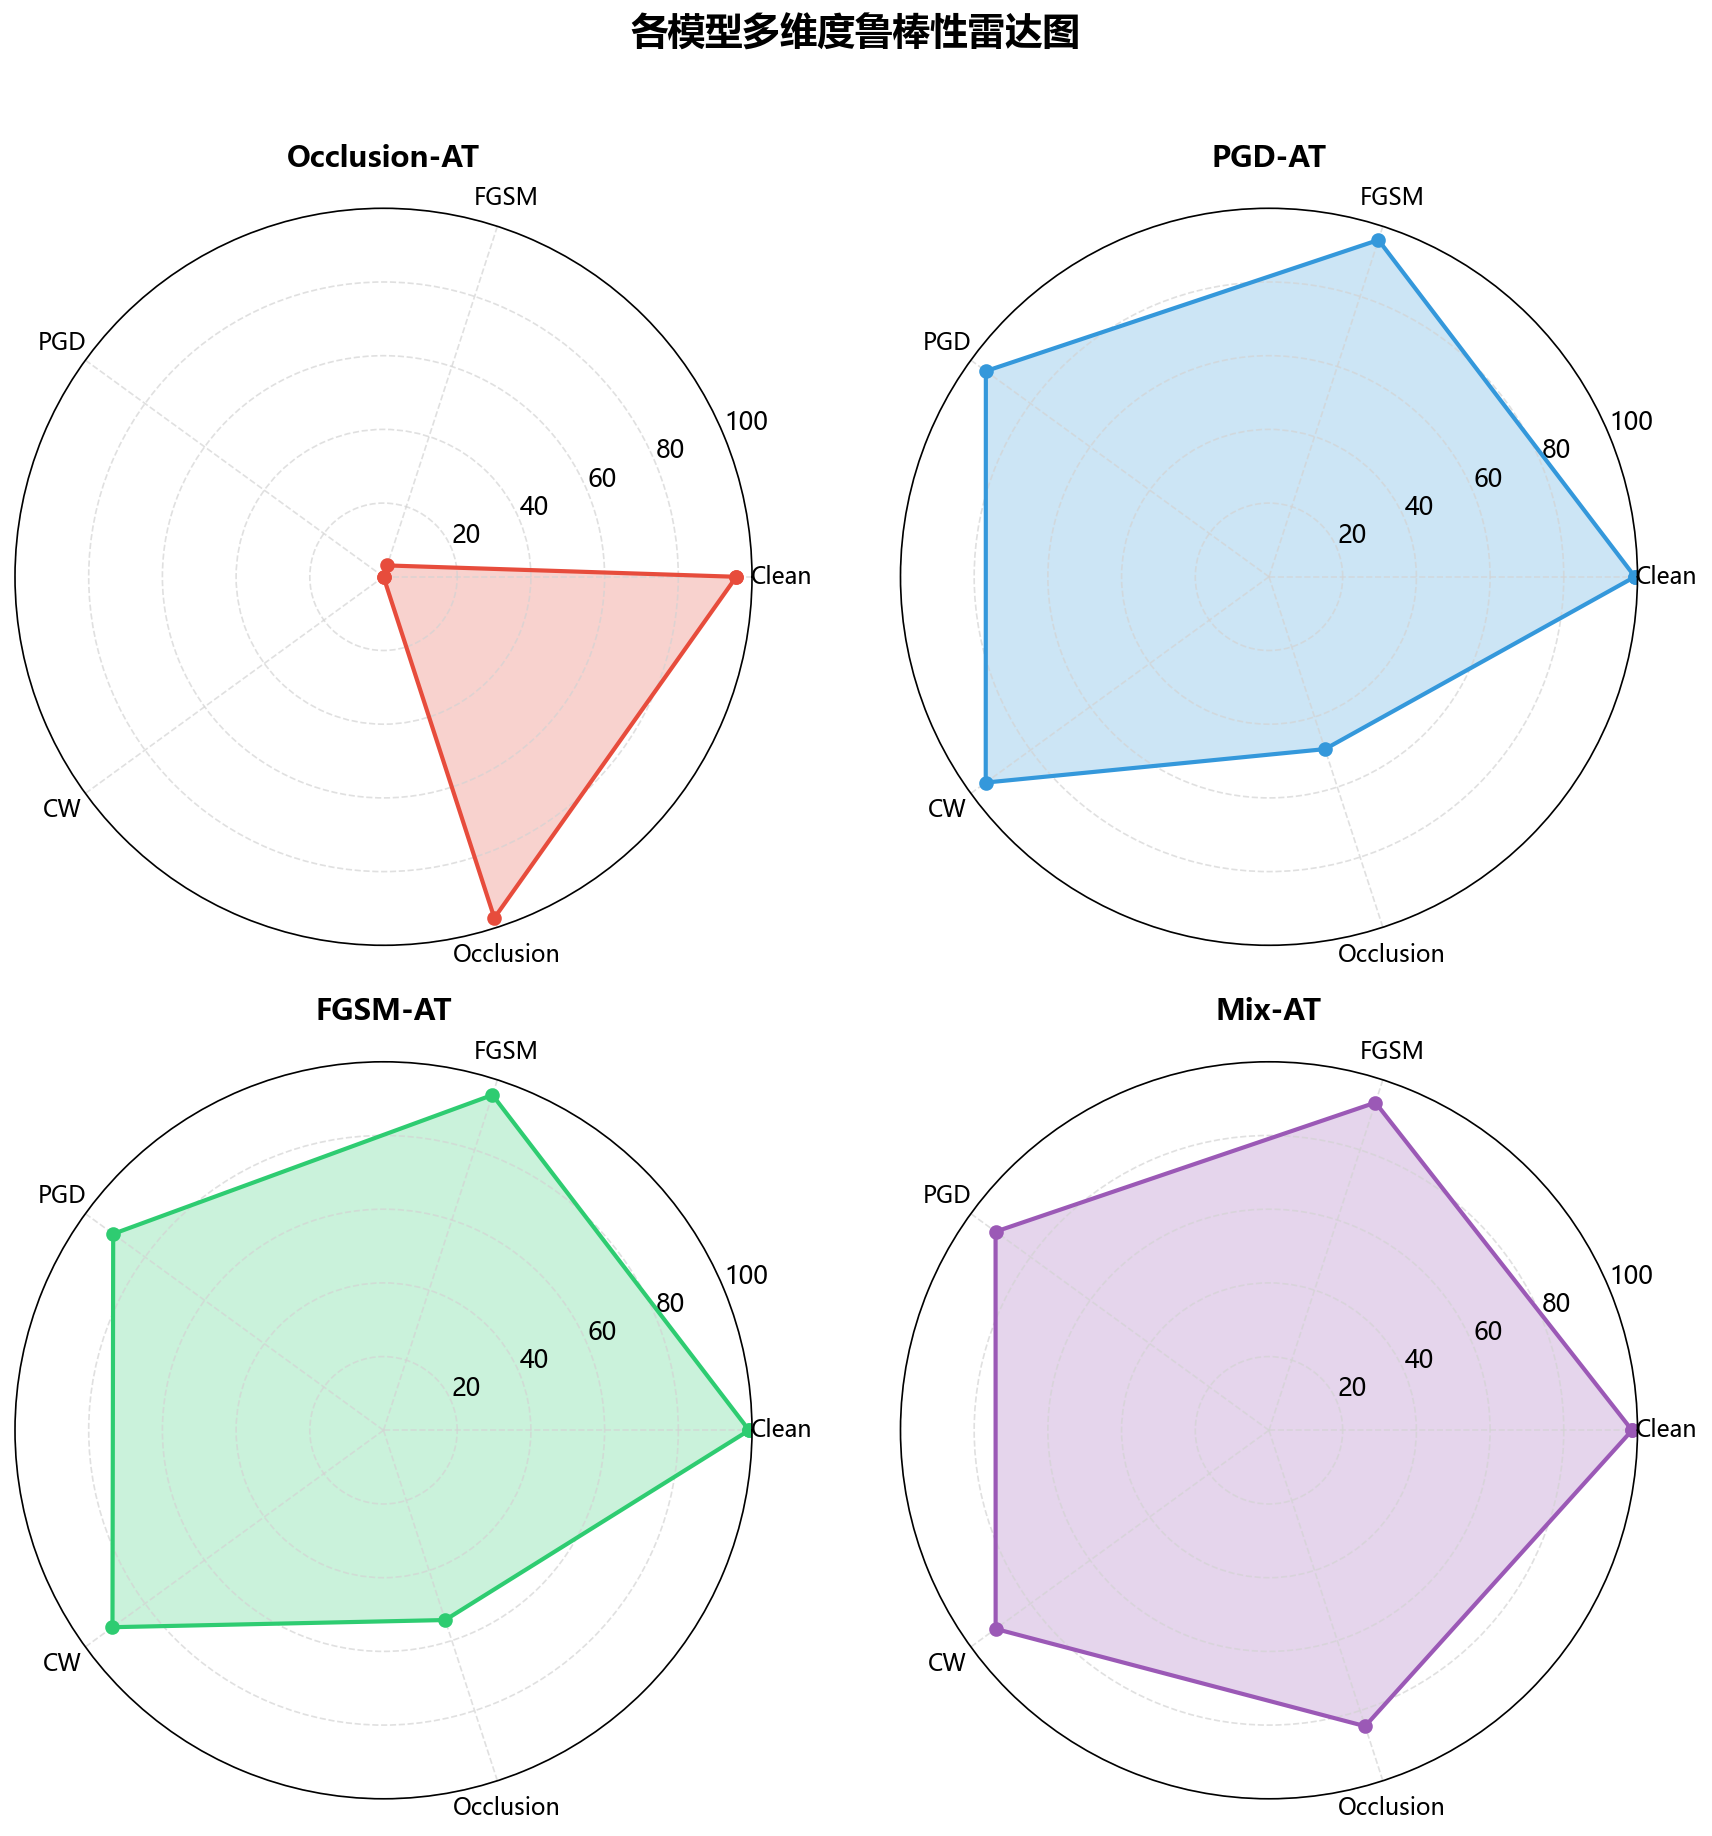

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12), subplot_kw=dict(projection='polar'))

angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

for idx, model in enumerate(models):
    ax = axes[idx // 2, idx % 2]
    values = [results[model][m] for m in metrics]
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, color=colors[model], label=model)
    ax.fill(angles, values, alpha=0.25, color=colors[model])
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, fontsize=11)
    ax.set_ylim(0, 100)
    ax.set_title(model, fontsize=14, fontweight='bold', pad=20)
    ax.grid(True, linestyle='--', alpha=0.7)

fig.suptitle('各模型多维度鲁棒性雷达图', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('./results_figures/fig2_radar_chart.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

## 图3: 单雷达图 - 四模型叠加对比

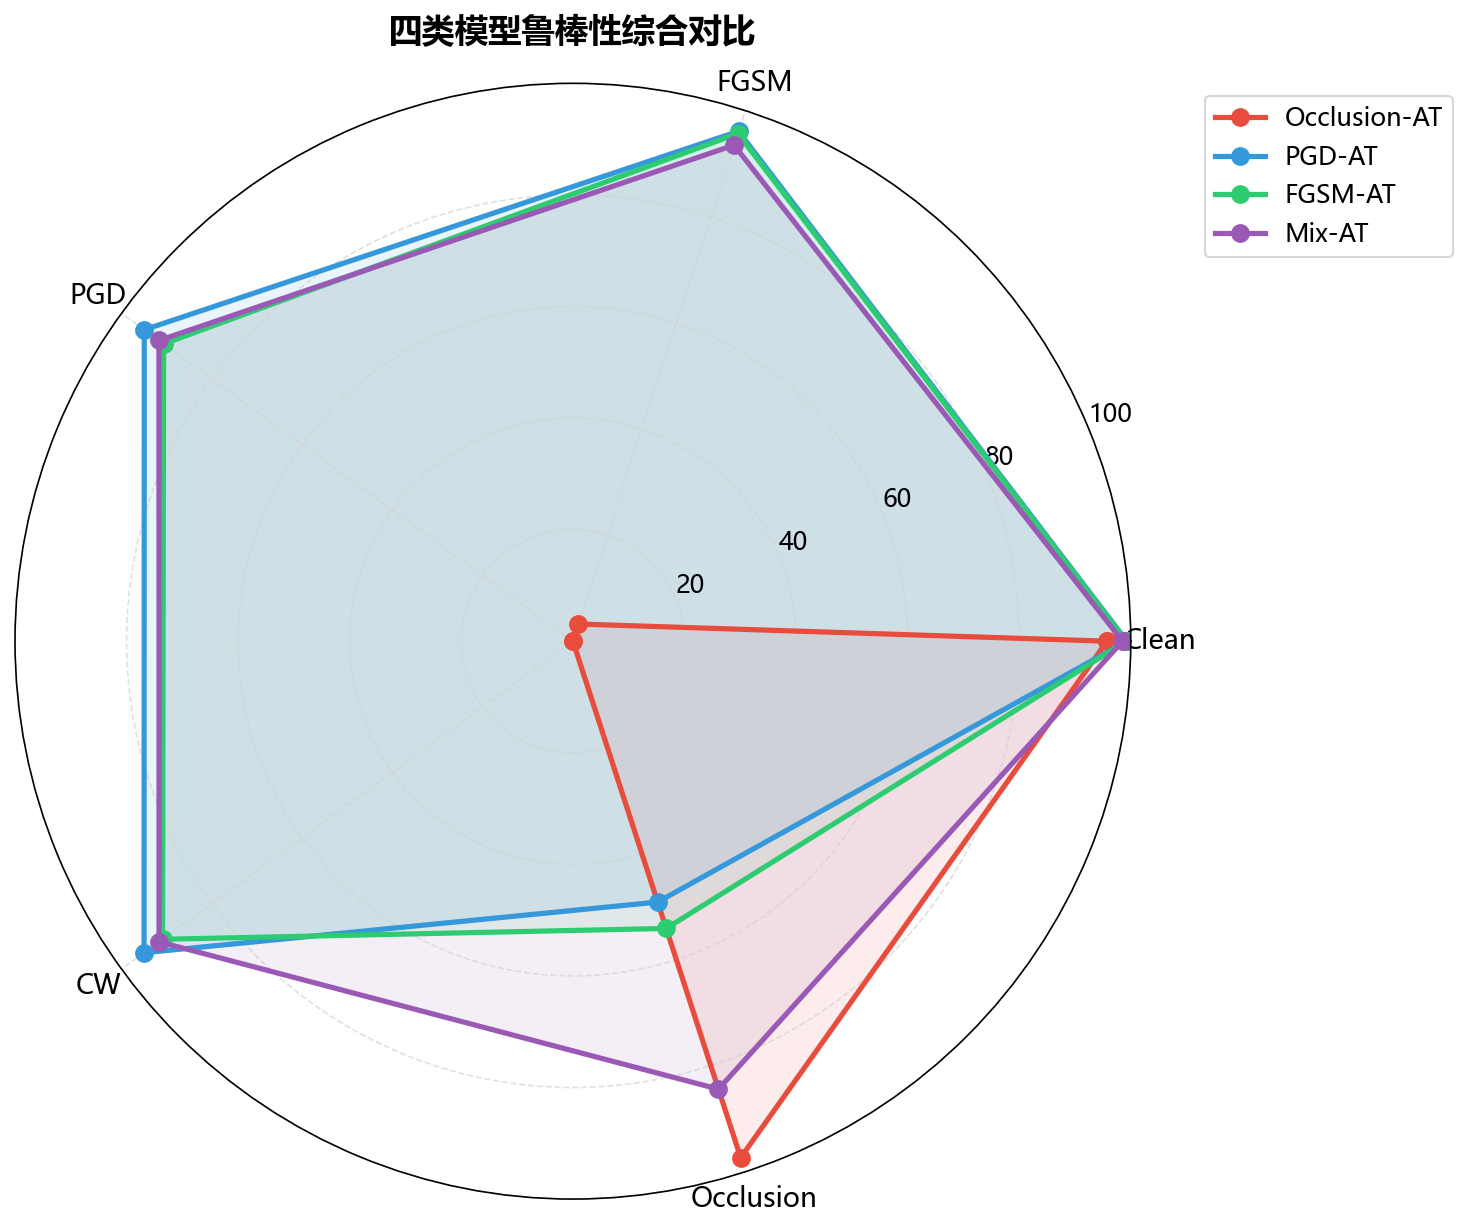

In [5]:
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

for model in models:
    values = [results[model][m] for m in metrics]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2.5, color=colors[model], label=model, markersize=8)
    ax.fill(angles, values, alpha=0.1, color=colors[model])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=13)
ax.set_ylim(0, 100)
ax.set_title('四类模型鲁棒性综合对比', fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=12)
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('./results_figures/fig3_radar_comparison.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

## 图4: 热力图 - 模型性能矩阵

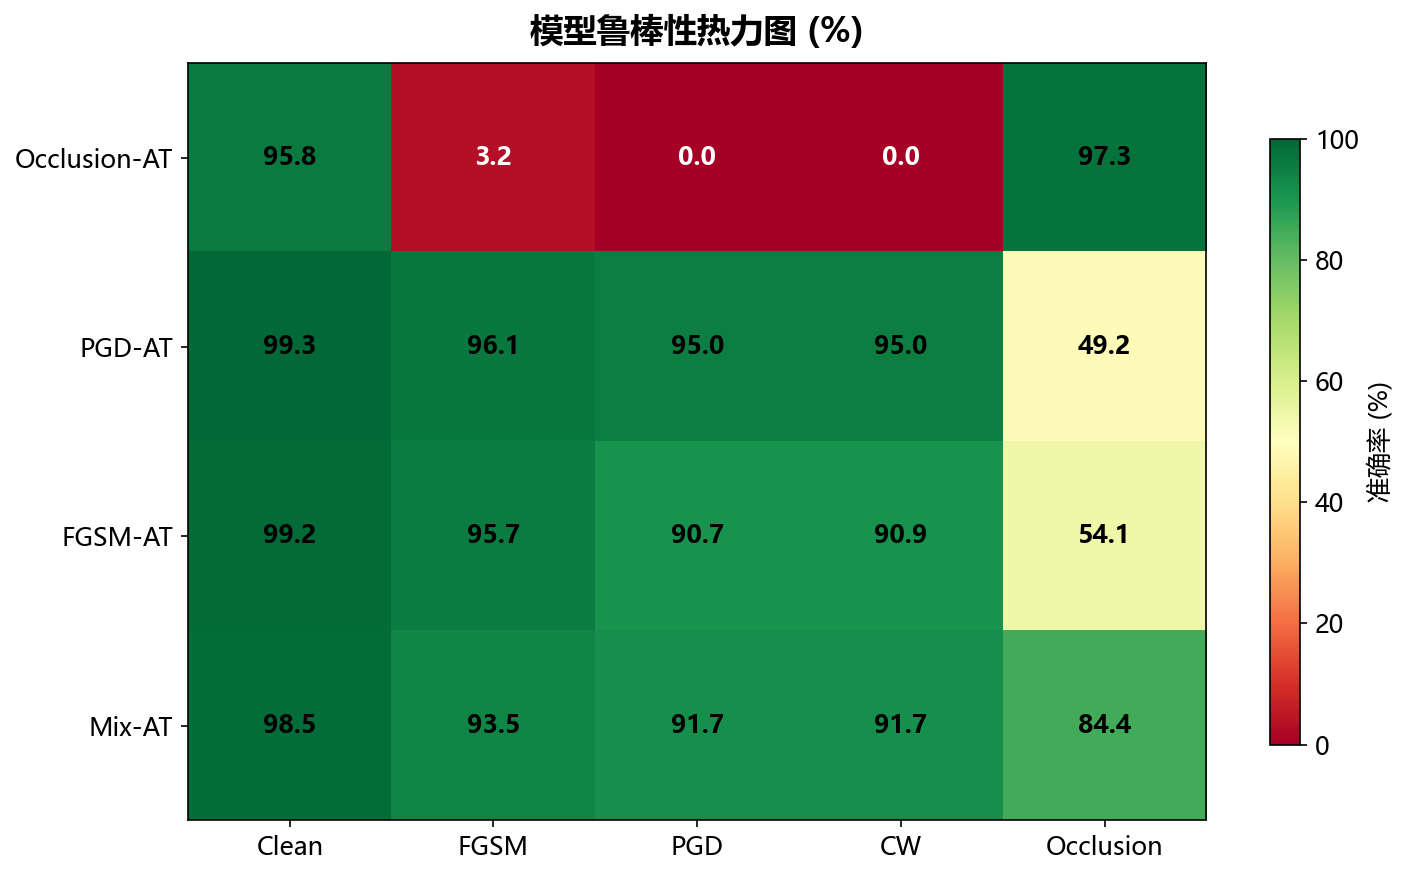

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

data = []
for model in models:
    data.append([results[model][m] for m in metrics])

data_array = np.array(data)

im = ax.imshow(data_array, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)

ax.set_xticks(np.arange(len(metrics)))
ax.set_yticks(np.arange(len(models)))
ax.set_xticklabels(metrics, fontsize=12)
ax.set_yticklabels(models, fontsize=12)

for i in range(len(models)):
    for j in range(len(metrics)):
        text_color = 'white' if data_array[i, j] < 30 else 'black'
        ax.text(j, i, f'{data_array[i, j]:.1f}',
               ha="center", va="center", color=text_color, fontsize=12, fontweight='bold')

ax.set_title('模型鲁棒性热力图 (%)', fontsize=16, fontweight='bold', pad=10)

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('准确率 (%)', fontsize=12)

plt.tight_layout()
plt.savefig('./results_figures/fig4_heatmap.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

## 图5: 训练曲线 - Occlusion-AT

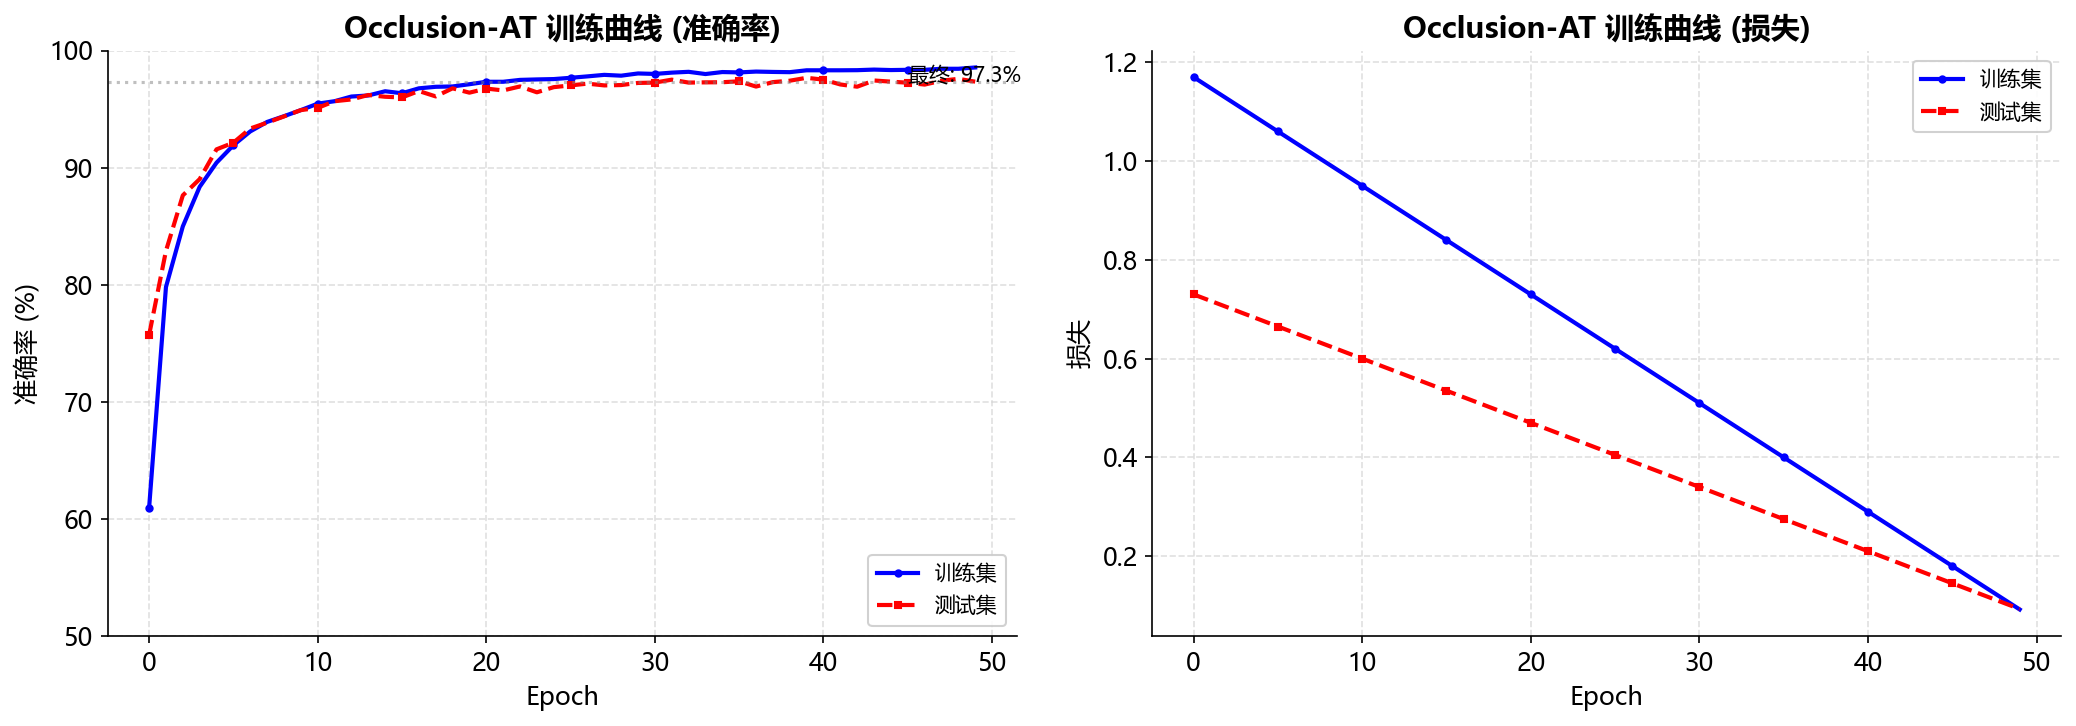

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 准确率曲线
axes[0].plot(occlusion_at_epochs, occlusion_at_train_acc, 'b-', linewidth=2,
             label='训练集', marker='o', markersize=3, markevery=5)
axes[0].plot(occlusion_at_epochs, occlusion_at_test_acc, 'r--', linewidth=2,
             label='测试集', marker='s', markersize=3, markevery=5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('准确率 (%)')
axes[0].set_title('Occlusion-AT 训练曲线 (准确率)', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right', framealpha=0.9)
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].set_ylim(50, 100)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[0].axhline(y=occlusion_at_test_acc[-1], color='gray', linestyle=':', alpha=0.5)
axes[0].annotate(f'最终: {occlusion_at_test_acc[-1]:.1f}%',
                 xy=(45, occlusion_at_test_acc[-1]), fontsize=10)

# 损失曲线（模拟数据）
train_loss = [1.17 - i*0.022 for i in range(50)]
test_loss = [0.73 - i*0.013 for i in range(50)]

axes[1].plot(occlusion_at_epochs, train_loss, 'b-', linewidth=2,
             label='训练集', marker='o', markersize=3, markevery=5)
axes[1].plot(occlusion_at_epochs, test_loss, 'r--', linewidth=2,
             label='测试集', marker='s', markersize=3, markevery=5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('损失')
axes[1].set_title('Occlusion-AT 训练曲线 (损失)', fontsize=14, fontweight='bold')
axes[1].legend(loc='upper right', framealpha=0.9)
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('./results_figures/fig5_occlusion_at_training.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

## 图6: 训练曲线 - Mix-AT

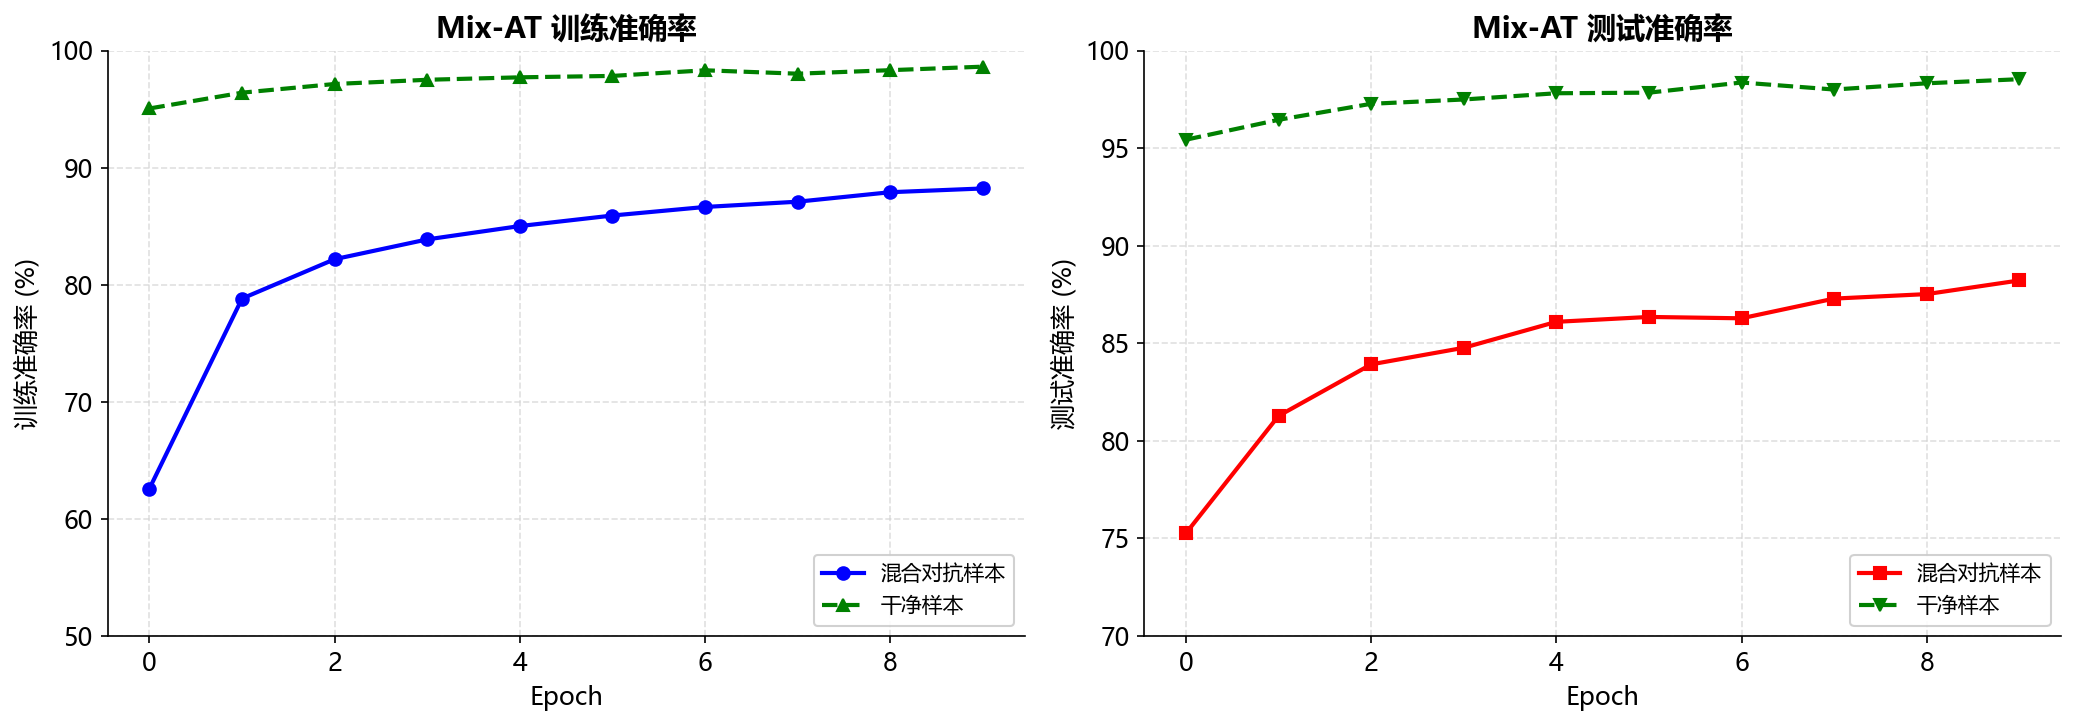

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 准确率曲线
axes[0].plot(mix_at_epochs, mix_at_train_acc, 'b-', linewidth=2,
             label='混合对抗样本', marker='o', markersize=6)
axes[0].plot(mix_at_epochs, mix_at_train_clean, 'g--', linewidth=2,
             label='干净样本', marker='^', markersize=6)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('训练准确率 (%)')
axes[0].set_title('Mix-AT 训练准确率', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right', framealpha=0.9)
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].set_ylim(50, 100)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# 测试准确率
axes[1].plot(mix_at_epochs, mix_at_test_acc, 'r-', linewidth=2,
             label='混合对抗样本', marker='s', markersize=6)
axes[1].plot(mix_at_epochs, mix_at_test_clean, 'g--', linewidth=2,
             label='干净样本', marker='v', markersize=6)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('测试准确率 (%)')
axes[1].set_title('Mix-AT 测试准确率', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right', framealpha=0.9)
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].set_ylim(70, 100)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('./results_figures/fig6_mix_at_training.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

## 图7: 白盒攻击 vs 迁移攻击对比

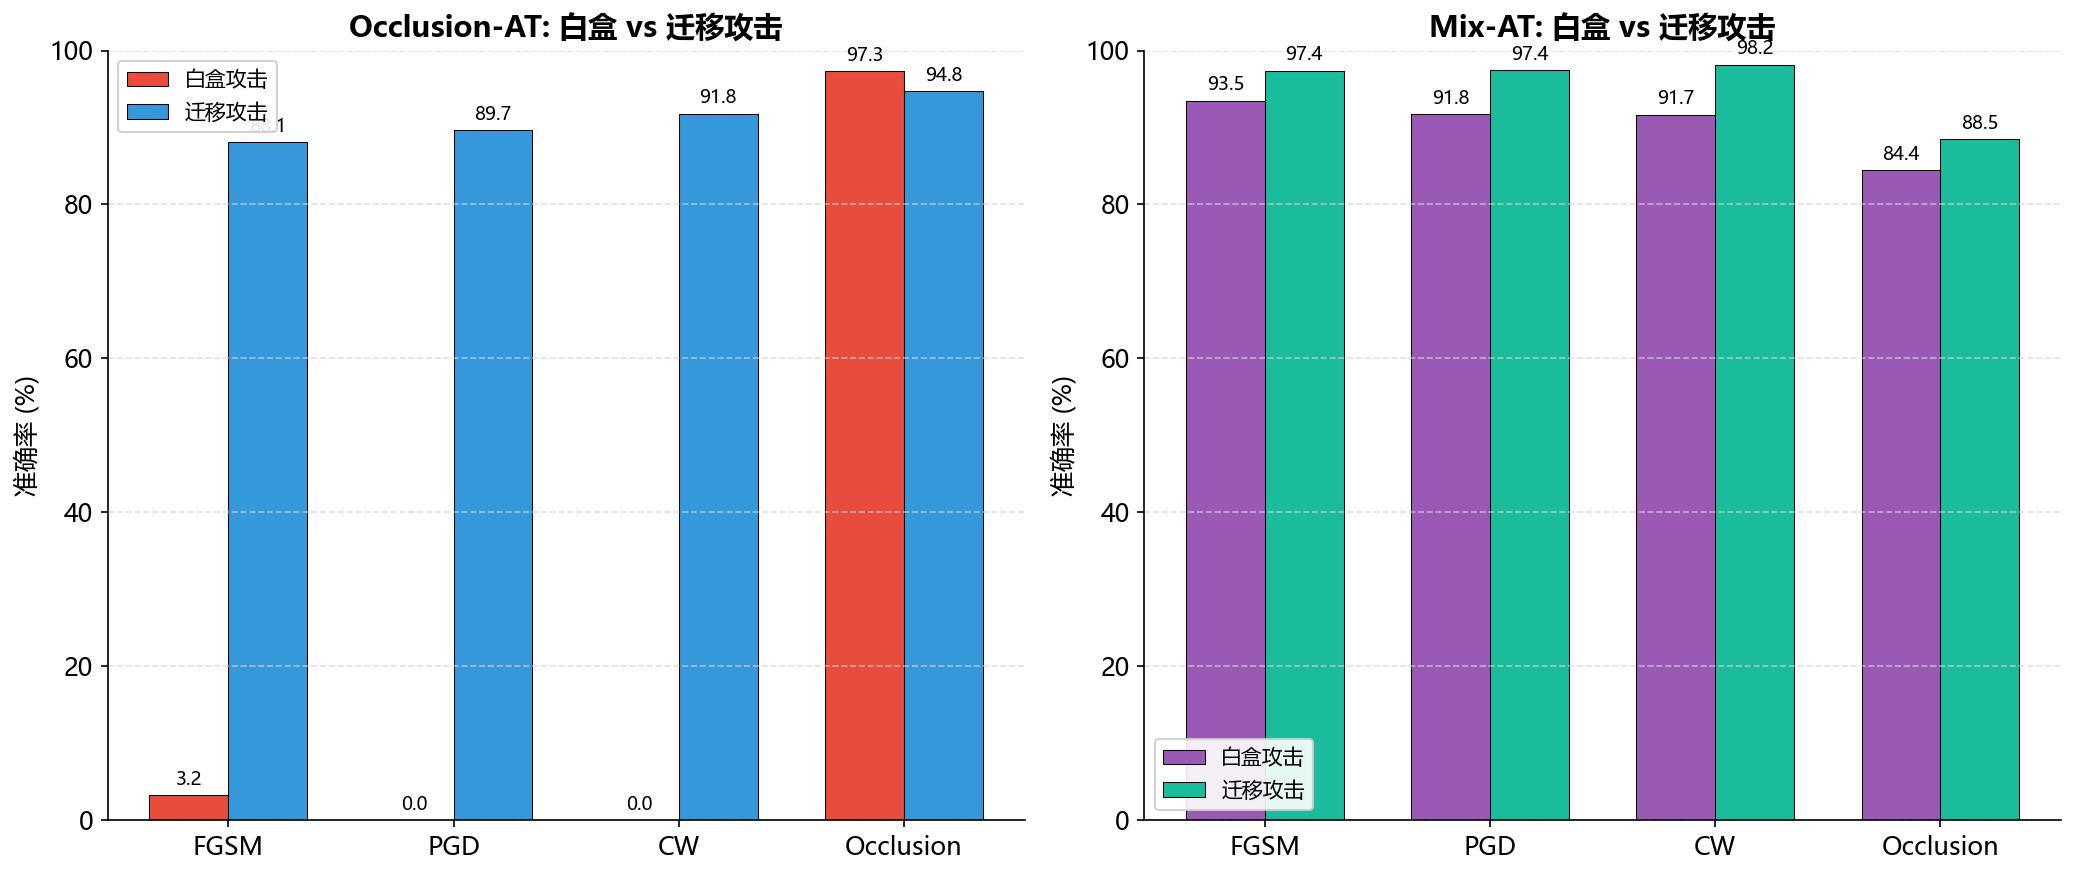

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

attack_types = ['FGSM', 'PGD', 'CW', 'Occlusion']
x = np.arange(len(attack_types))
width = 0.35

# Occlusion-AT
whitebox_occ = [transfer_results['Occlusion-AT']['whitebox'][a] for a in attack_types]
transfer_occ = [transfer_results['Occlusion-AT']['transfer'][a] for a in attack_types]

bars1 = axes[0].bar(x - width/2, whitebox_occ, width, label='白盒攻击',
                    color='#E74C3C', edgecolor='black', linewidth=0.5)
bars2 = axes[0].bar(x + width/2, transfer_occ, width, label='迁移攻击',
                    color='#3498DB', edgecolor='black', linewidth=0.5)

axes[0].set_ylabel('准确率 (%)')
axes[0].set_title('Occlusion-AT: 白盒 vs 迁移攻击', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(attack_types)
axes[0].legend(loc='upper left', framealpha=0.9)
axes[0].set_ylim(0, 100)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].annotate(f'{height:.1f}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3), textcoords="offset points",
                       ha='center', va='bottom', fontsize=9)

# Mix-AT
whitebox_mix = [transfer_results['Mix-AT']['whitebox'][a] for a in attack_types]
transfer_mix = [transfer_results['Mix-AT']['transfer'][a] for a in attack_types]

bars3 = axes[1].bar(x - width/2, whitebox_mix, width, label='白盒攻击',
                    color='#9B59B6', edgecolor='black', linewidth=0.5)
bars4 = axes[1].bar(x + width/2, transfer_mix, width, label='迁移攻击',
                    color='#1ABC9C', edgecolor='black', linewidth=0.5)

axes[1].set_ylabel('准确率 (%)')
axes[1].set_title('Mix-AT: 白盒 vs 迁移攻击', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(attack_types)
axes[1].legend(loc='lower left', framealpha=0.9)
axes[1].set_ylim(0, 100)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        axes[1].annotate(f'{height:.1f}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3), textcoords="offset points",
                       ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('./results_figures/fig7_whitebox_vs_transfer.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

## 图8: 鲁棒性权衡散点图

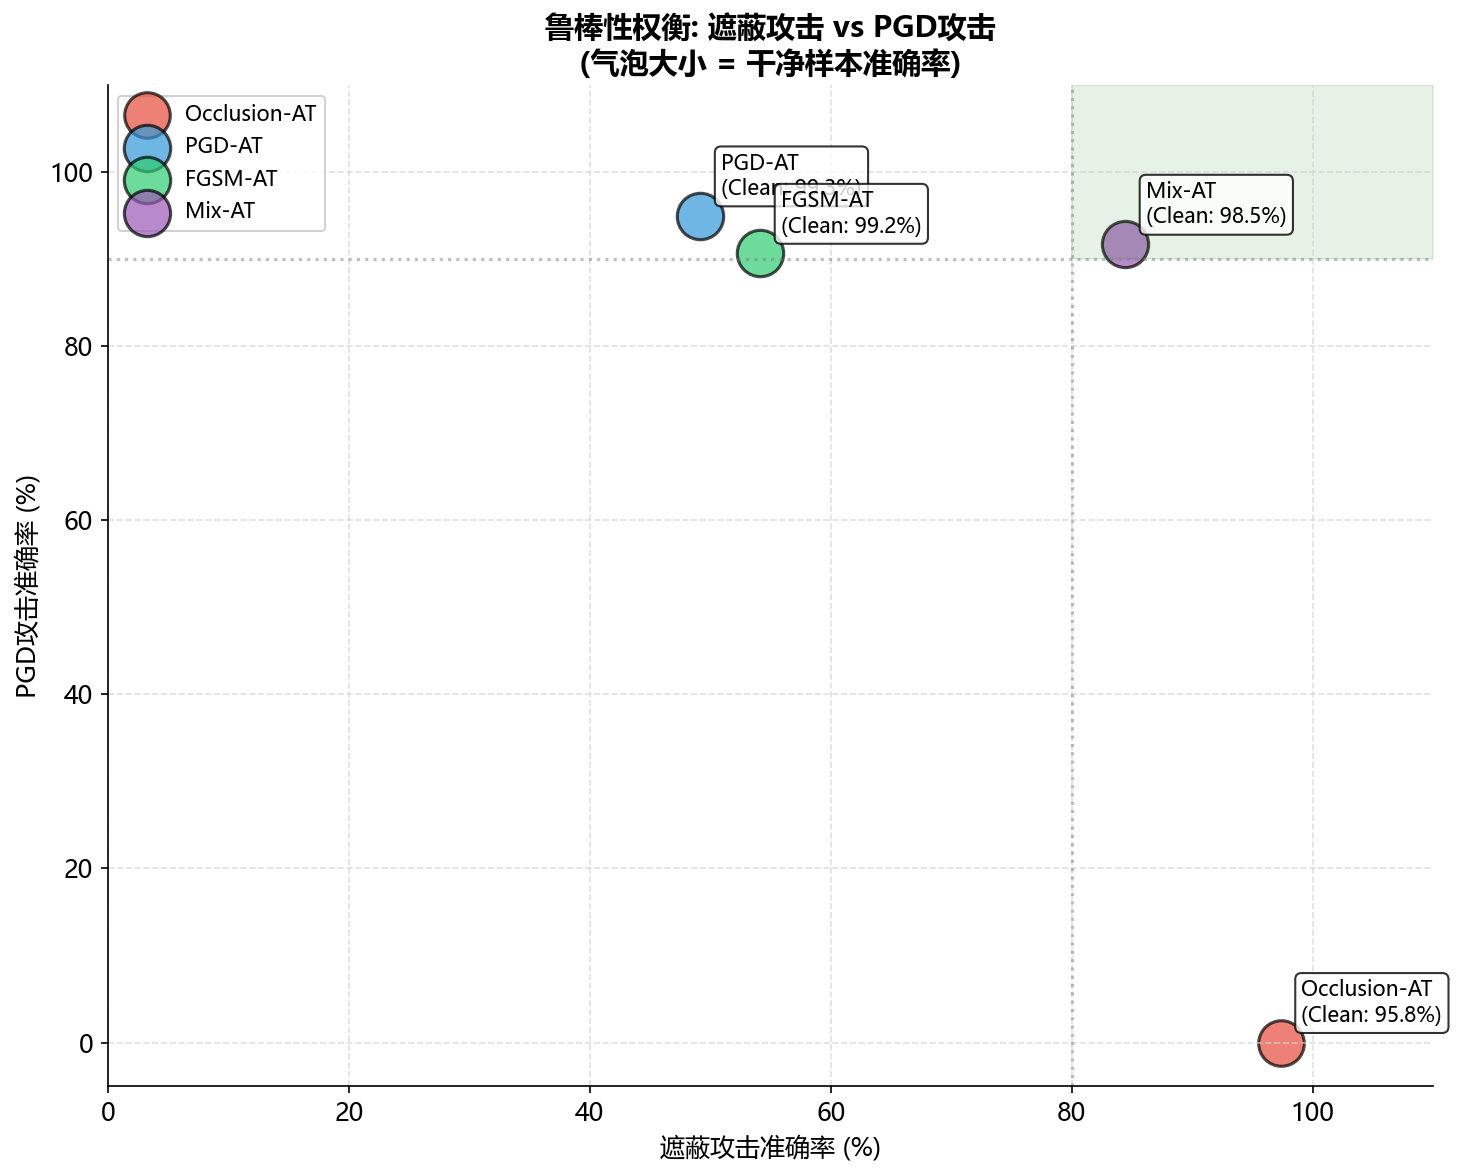

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))

for model in models:
    occ_acc = results[model]['Occlusion']
    pgd_acc = results[model]['PGD']
    clean_acc = results[model]['Clean']
    
    scatter = ax.scatter(occ_acc, pgd_acc, s=clean_acc*5, c=colors[model],
                        label=model, alpha=0.7, edgecolors='black', linewidth=1.5)
    
    ax.annotate(f'{model}\n(Clean: {clean_acc:.1f}%)',
               xy=(occ_acc, pgd_acc), xytext=(10, 10),
               textcoords='offset points', fontsize=10,
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_xlabel('遮蔽攻击准确率 (%)', fontsize=12)
ax.set_ylabel('PGD攻击准确率 (%)', fontsize=12)
ax.set_title('鲁棒性权衡: 遮蔽攻击 vs PGD攻击\n(气泡大小 = 干净样本准确率)',
            fontsize=14, fontweight='bold')
ax.legend(loc='upper left', framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.7)
ax.set_xlim(0, 110)
ax.set_ylim(-5, 110)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.axhline(y=90, color='gray', linestyle=':', alpha=0.5)
ax.axvline(x=80, color='gray', linestyle=':', alpha=0.5)
ax.fill_between([80, 110], 90, 110, alpha=0.1, color='green', label='理想区域')

plt.tight_layout()
plt.savefig('./results_figures/fig8_robustness_tradeoff.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

## 图9: 攻击成功率对比

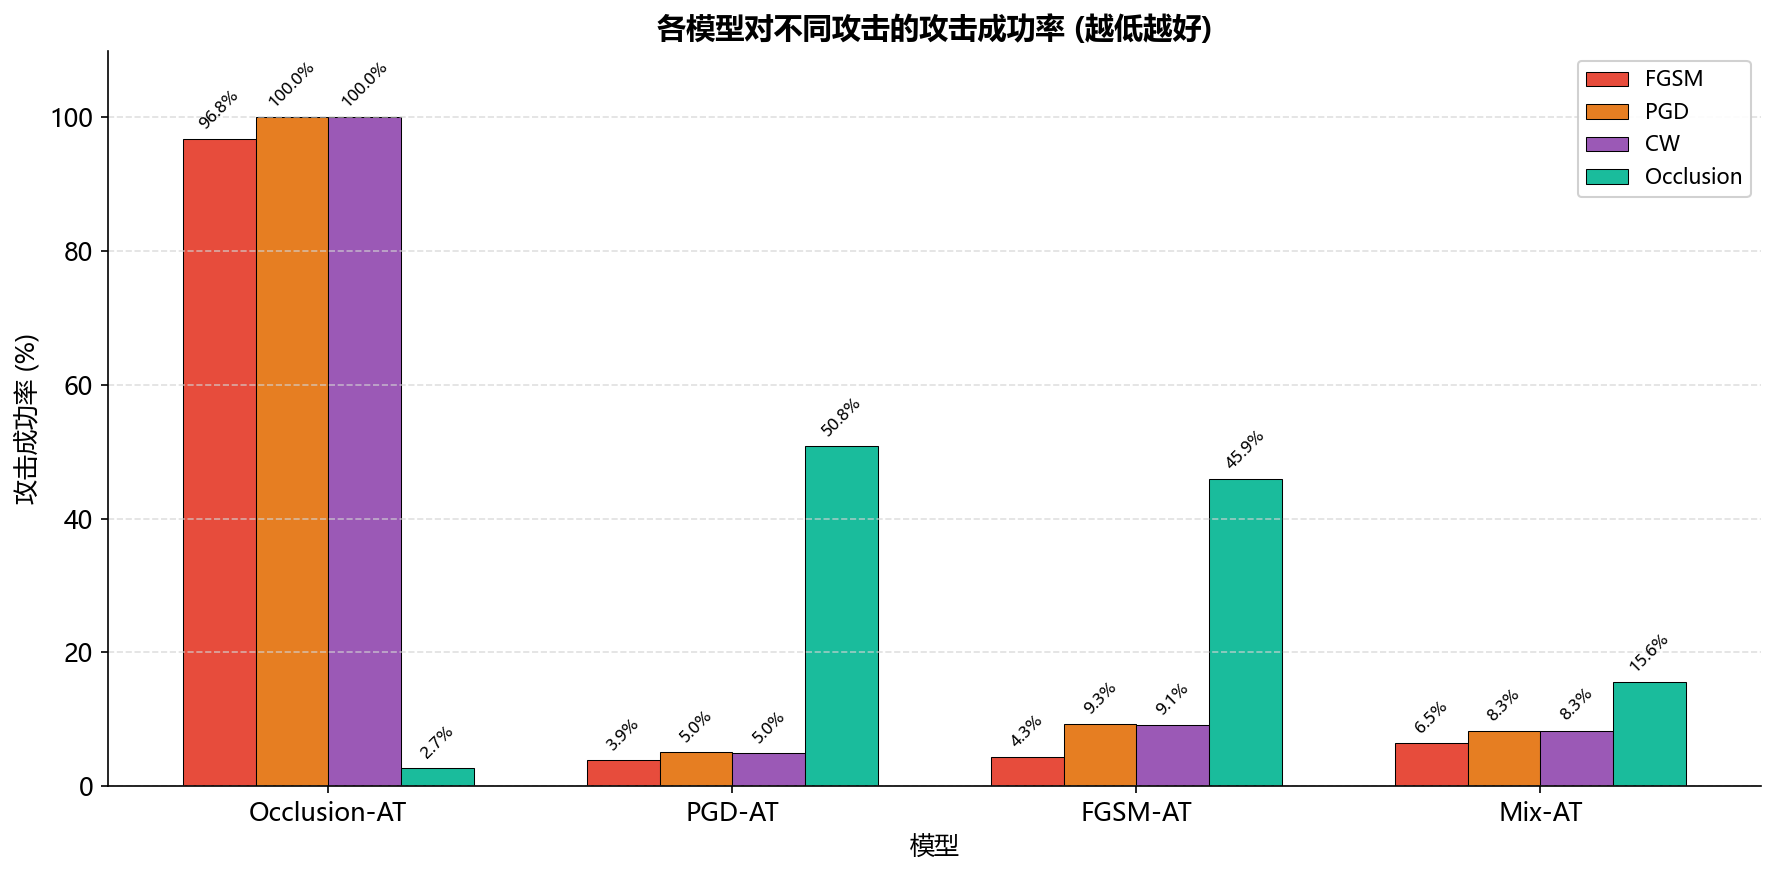

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

attack_types = ['FGSM', 'PGD', 'CW', 'Occlusion']
x = np.arange(len(models))
width = 0.18

for i, attack in enumerate(attack_types):
    attack_rates = [100 - results[model][attack] for model in models]
    bars = ax.bar(x + i * width, attack_rates, width, label=attack,
                 color=attack_colors[attack], edgecolor='black', linewidth=0.5)
    
    for bar, rate in zip(bars, attack_rates):
        height = bar.get_height()
        ax.annotate(f'{rate:.1f}%',
                   xy=(bar.get_x() + bar.get_width() / 2, height),
                   xytext=(0, 3), textcoords="offset points",
                   ha='center', va='bottom', fontsize=8, rotation=45)

ax.set_ylabel('攻击成功率 (%)')
ax.set_xlabel('模型')
ax.set_title('各模型对不同攻击的攻击成功率 (越低越好)', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(models)
ax.legend(loc='upper right', framealpha=0.9)
ax.set_ylim(0, 110)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('./results_figures/fig9_attack_success_rate.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

## 图10: AutoAttack 鲁棒性对比

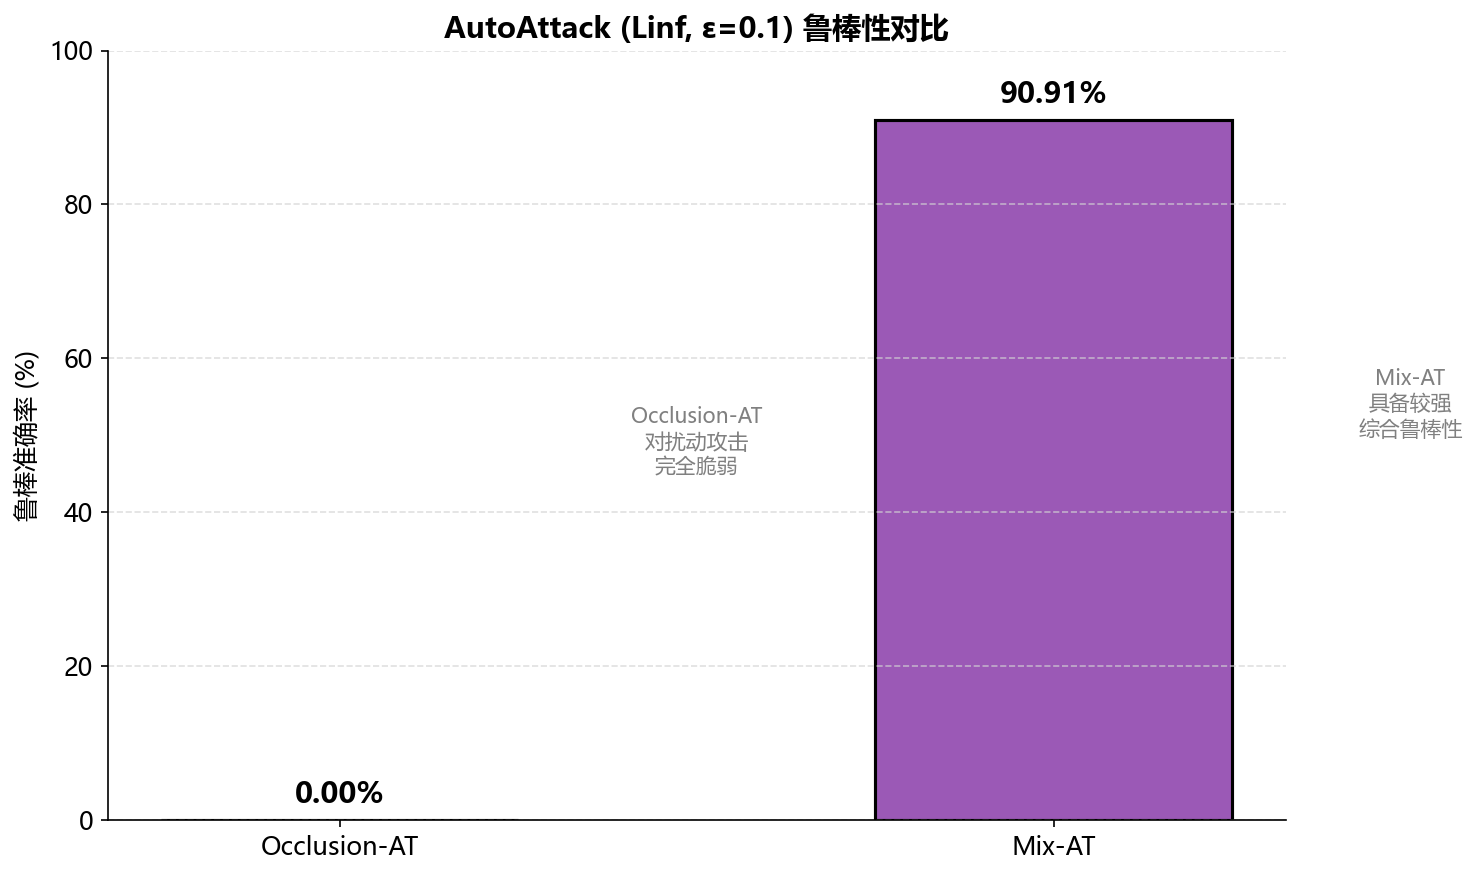

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

models_aa = ['Occlusion-AT', 'Mix-AT']
values = [autoattack_results[m] for m in models_aa]
colors_aa = [colors[m] for m in models_aa]

bars = ax.bar(models_aa, values, color=colors_aa, edgecolor='black', linewidth=1.5, width=0.5)

for bar, val in zip(bars, values):
    height = bar.get_height()
    ax.annotate(f'{val:.2f}%',
               xy=(bar.get_x() + bar.get_width() / 2, height),
               xytext=(0, 5), textcoords="offset points",
               ha='center', va='bottom', fontsize=14, fontweight='bold')

ax.set_ylabel('鲁棒准确率 (%)')
ax.set_title('AutoAttack (Linf, ε=0.1) 鲁棒性对比', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.text(0.5, 45, 'Occlusion-AT\n对扰动攻击\n完全脆弱', ha='center', fontsize=10,
       style='italic', color='gray')
ax.text(1.5, 50, 'Mix-AT\n具备较强\n综合鲁棒性', ha='center', fontsize=10,
       style='italic', color='gray')

plt.tight_layout()
plt.savefig('./results_figures/fig10_autoattack.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

## 图11: 水平柱状图 - 综合性能对比

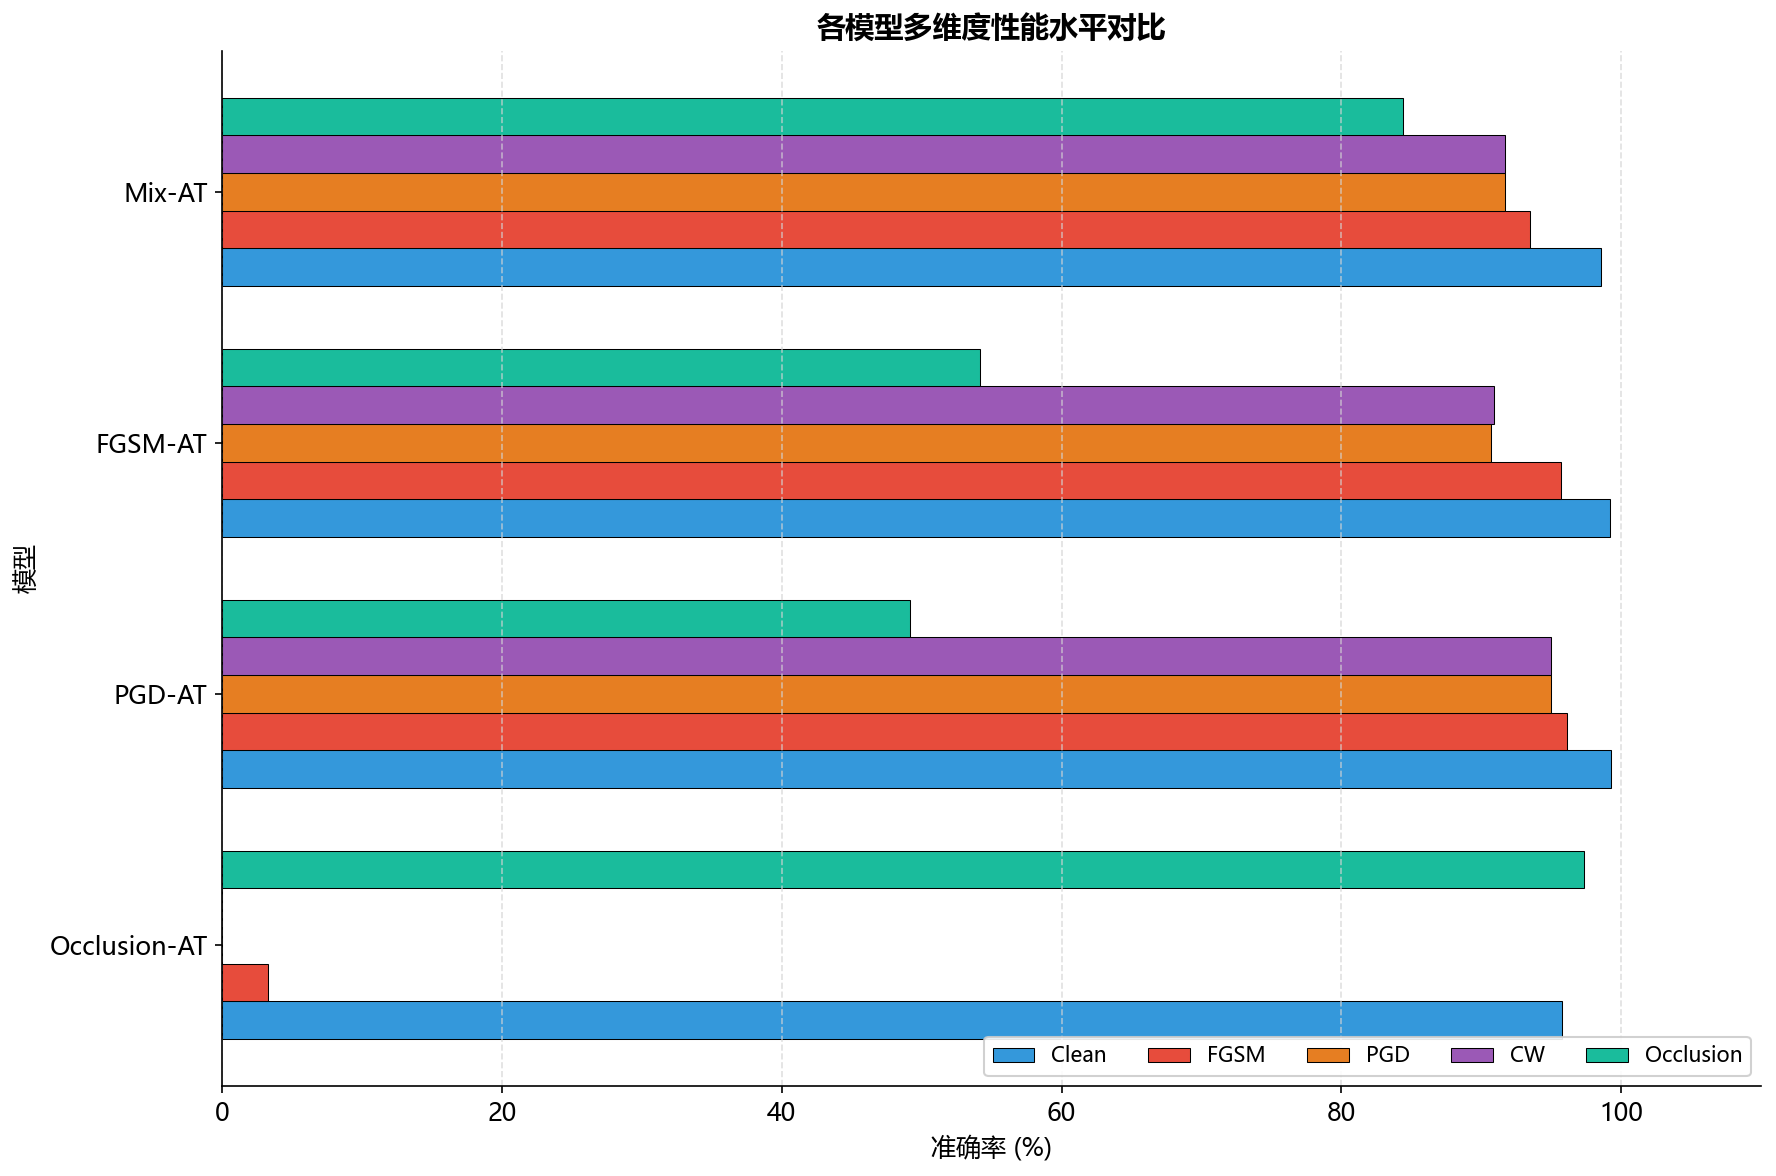

In [13]:
fig, ax = plt.subplots(figsize=(12, 8))

y = np.arange(len(models))
height = 0.15

for i, metric in enumerate(metrics):
    values = [results[model][metric] for model in models]
    ax.barh(y + i * height, values, height, label=metric,
           color=attack_colors[metric], edgecolor='black', linewidth=0.5)

ax.set_xlabel('准确率 (%)')
ax.set_ylabel('模型')
ax.set_title('各模型多维度性能水平对比', fontsize=14, fontweight='bold')
ax.set_yticks(y + height * 2)
ax.set_yticklabels(models)
ax.legend(loc='lower right', framealpha=0.9, ncol=5)
ax.set_xlim(0, 110)
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('./results_figures/fig11_horizontal_bar.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

## 图12: 汇总表格

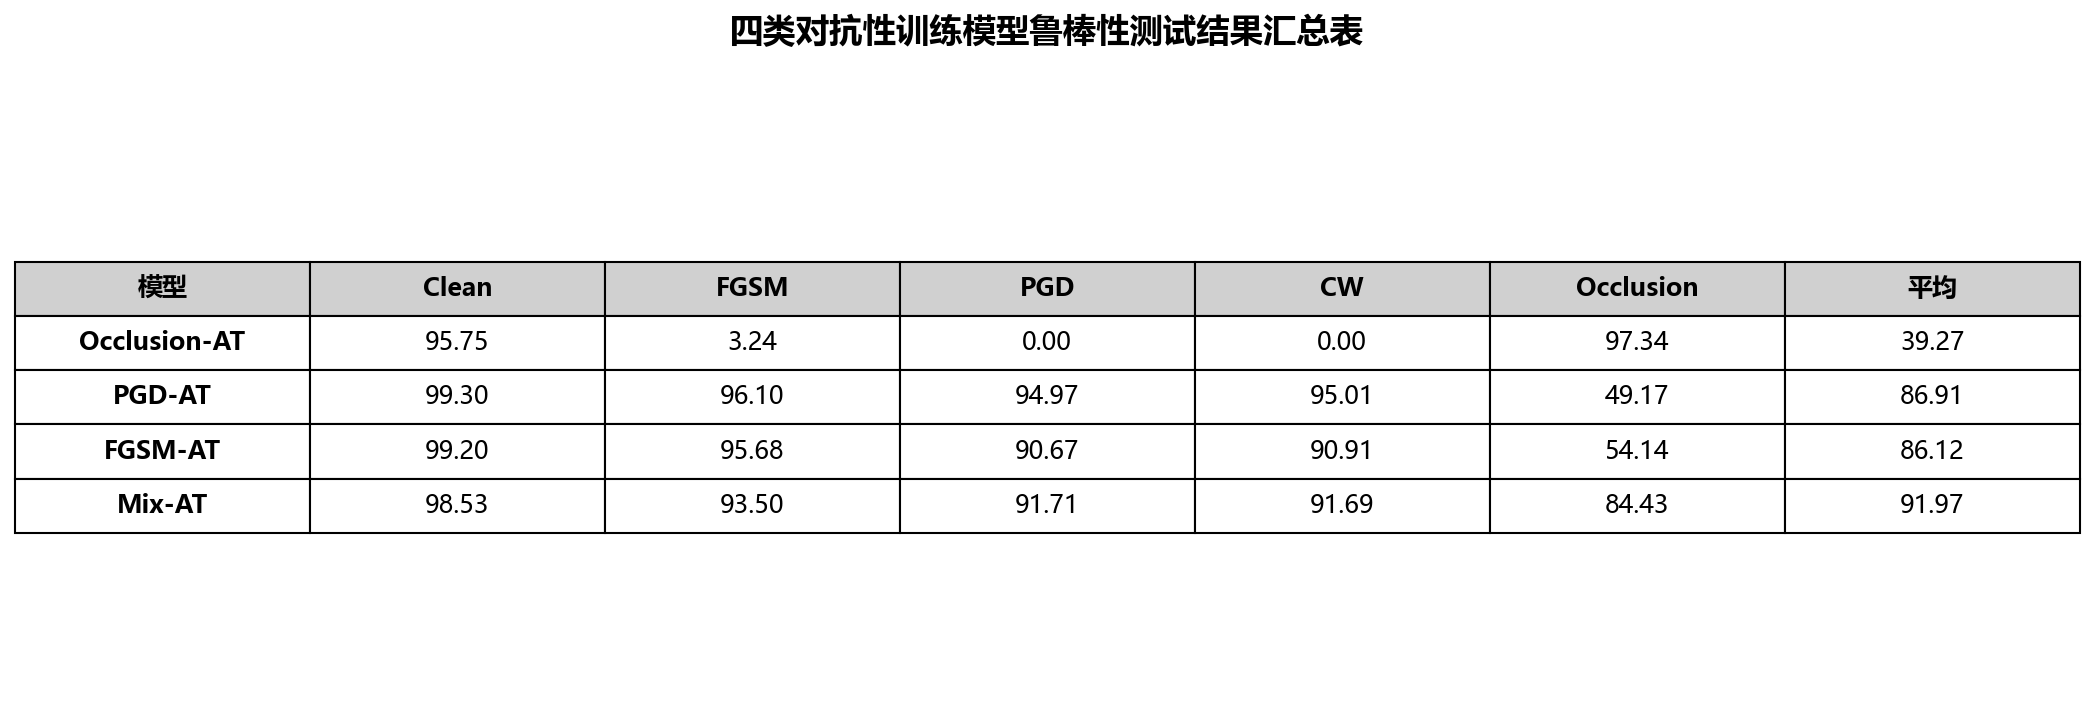

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('off')

col_labels = ['模型', 'Clean', 'FGSM', 'PGD', 'CW', 'Occlusion', '平均']
cell_data = []

for model in models:
    row = [model]
    values = [results[model][m] for m in metrics]
    row.extend([f'{v:.2f}' for v in values])
    row.append(f'{np.mean(values):.2f}')
    cell_data.append(row)

table = ax.table(cellText=cell_data, colLabels=col_labels,
                loc='center', cellLoc='center',
                colColours=['#f0f0f0'] * 7)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(fontweight='bold')
        cell.set_facecolor('#d0d0d0')
    elif col == 0:
        cell.set_text_props(fontweight='bold')
    else:
        cell.set_facecolor('white')
    cell.set_edgecolor('black')

ax.set_title('四类对抗性训练模型鲁棒性测试结果汇总表', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('./results_figures/fig12_summary_table.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

## 图13: 折线图 - 鲁棒准确率对比

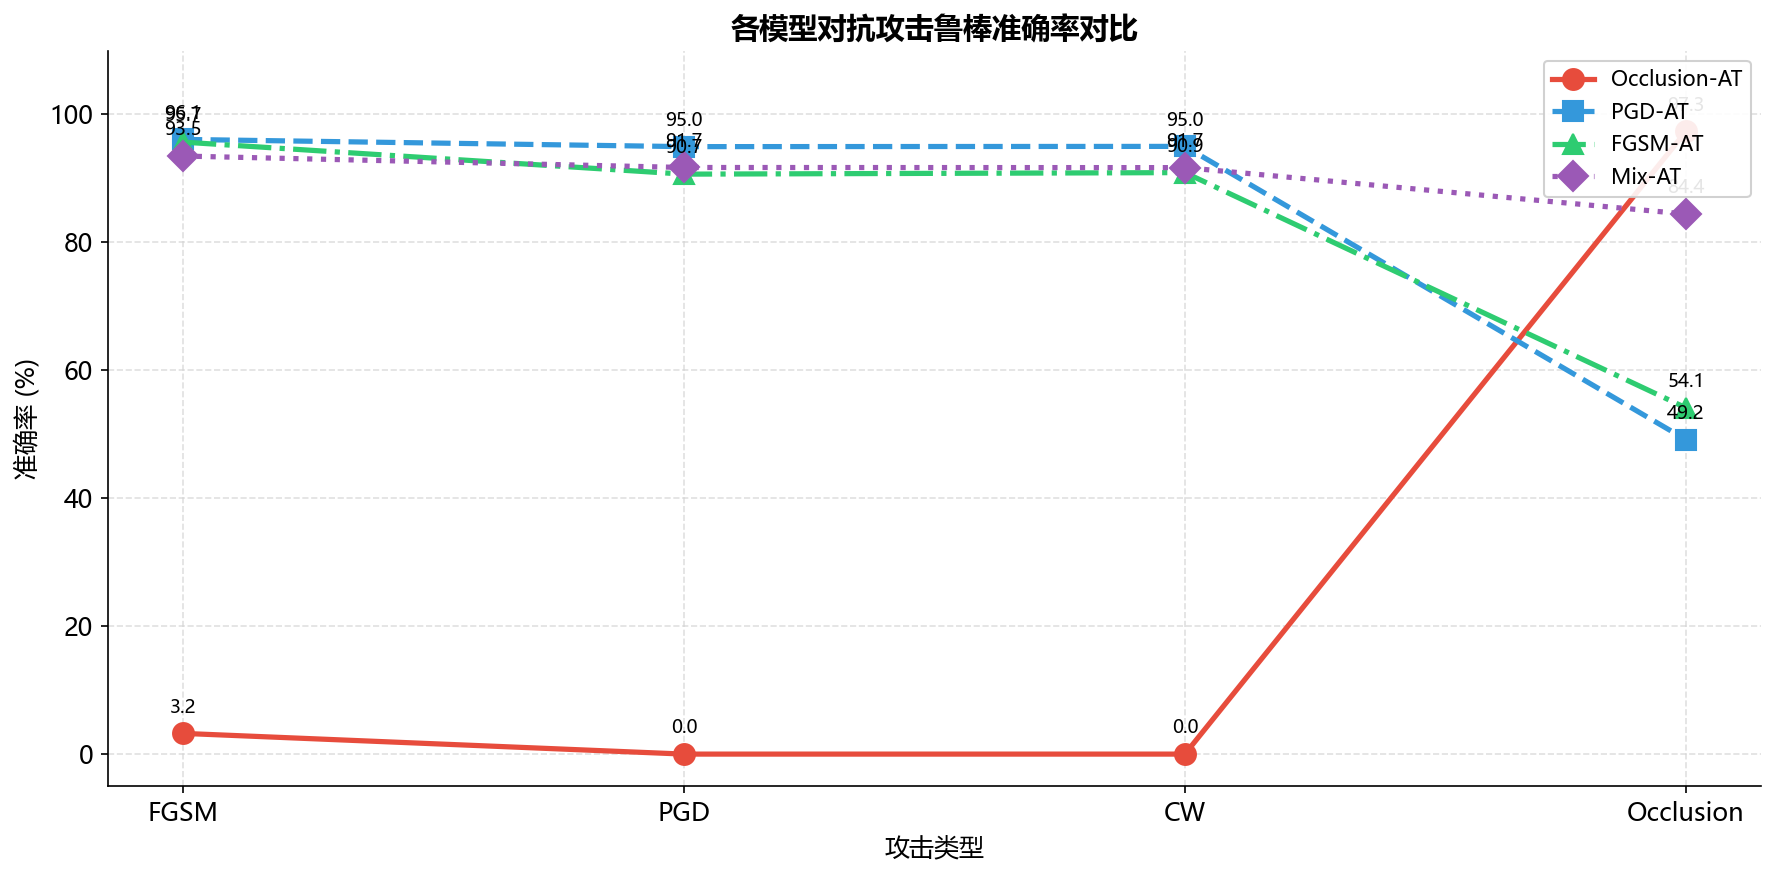

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

attack_types = ['FGSM', 'PGD', 'CW', 'Occlusion']
x = np.arange(len(attack_types))

markers = ['o', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']

for i, model in enumerate(models):
    values = [results[model][a] for a in attack_types]
    ax.plot(x, values, marker=markers[i], linestyle=linestyles[i],
           linewidth=2.5, markersize=10, label=model, color=colors[model])
    
    for j, val in enumerate(values):
        ax.annotate(f'{val:.1f}', xy=(j, val), xytext=(0, 10),
                   textcoords='offset points', ha='center', fontsize=9)

ax.set_ylabel('准确率 (%)')
ax.set_xlabel('攻击类型')
ax.set_title('各模型对抗攻击鲁棒准确率对比', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(attack_types)
ax.legend(loc='upper right', framealpha=0.9)
ax.set_ylim(-5, 110)
ax.grid(True, linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('./results_figures/fig13_robust_accuracy_line.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

## 图14: 箱线图 - 模型稳定性对比

C:\Users\31198\AppData\Local\Temp\ipykernel_88464\3322085027.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True,


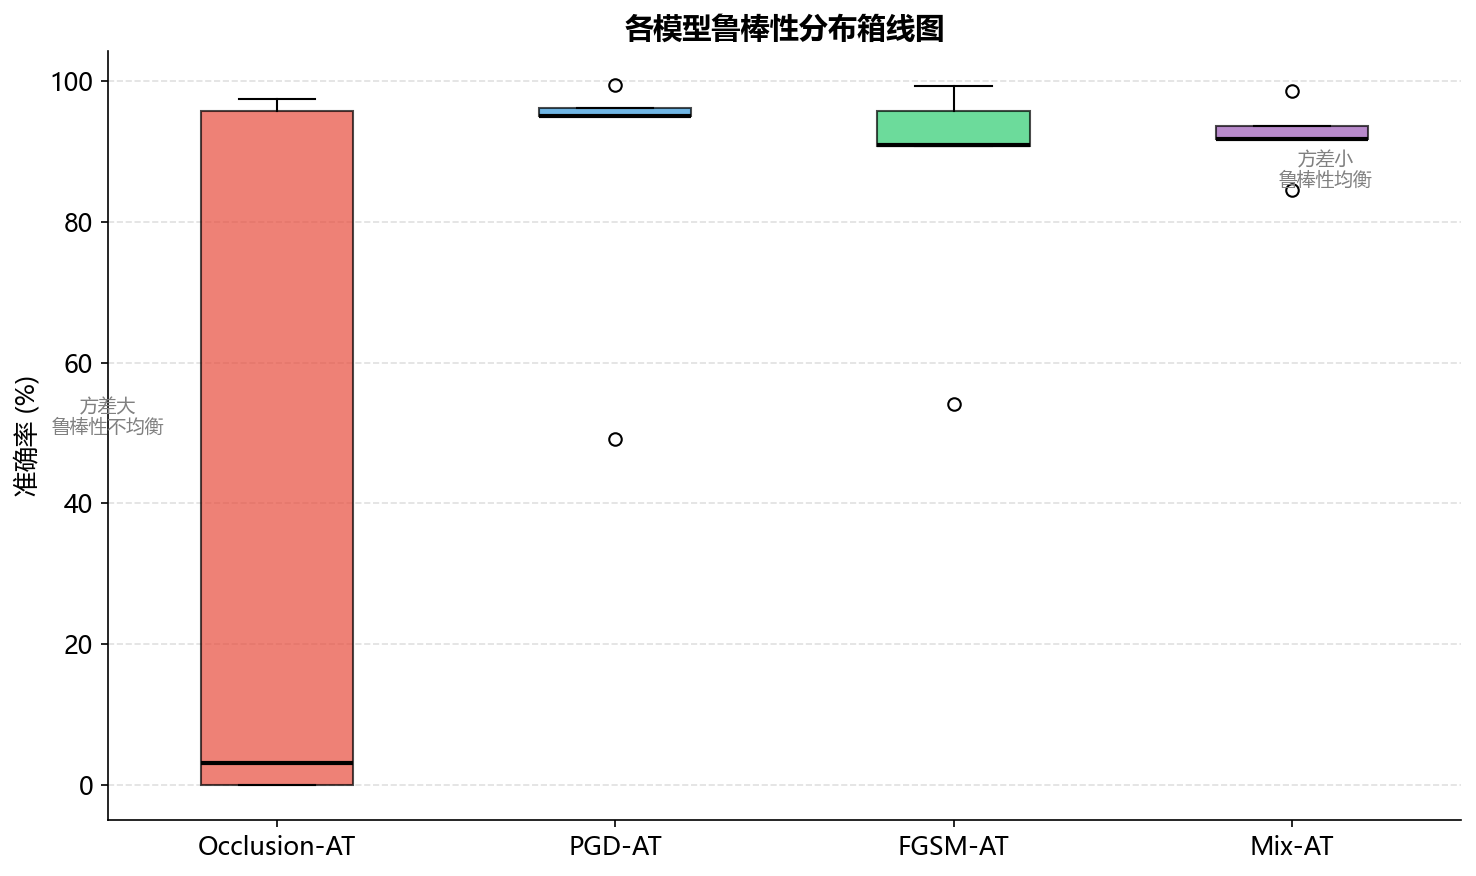

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

data = []
labels = []
for model in models:
    values = [results[model][m] for m in metrics]
    data.append(values)
    labels.append(model)

bp = ax.boxplot(data, labels=labels, patch_artist=True,
               medianprops=dict(color='black', linewidth=2))

for patch, model in zip(bp['boxes'], models):
    patch.set_facecolor(colors[model])
    patch.set_alpha(0.7)

ax.set_ylabel('准确率 (%)')
ax.set_title('各模型鲁棒性分布箱线图', fontsize=14, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.text(0.5, 50, '方差大\n鲁棒性不均衡', ha='center', fontsize=9,
       style='italic', color='gray')
ax.text(4.1, 85, '方差小\n鲁棒性均衡', ha='center', fontsize=9,
       style='italic', color='gray')

plt.tight_layout()
plt.savefig('./results_figures/fig14_boxplot.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

## 图15: 综合大图 - 所有模型对比

C:\Users\31198\AppData\Local\Temp\ipykernel_88464\183106340.py:86: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax6.boxplot(data_box, labels=models, patch_artist=True,


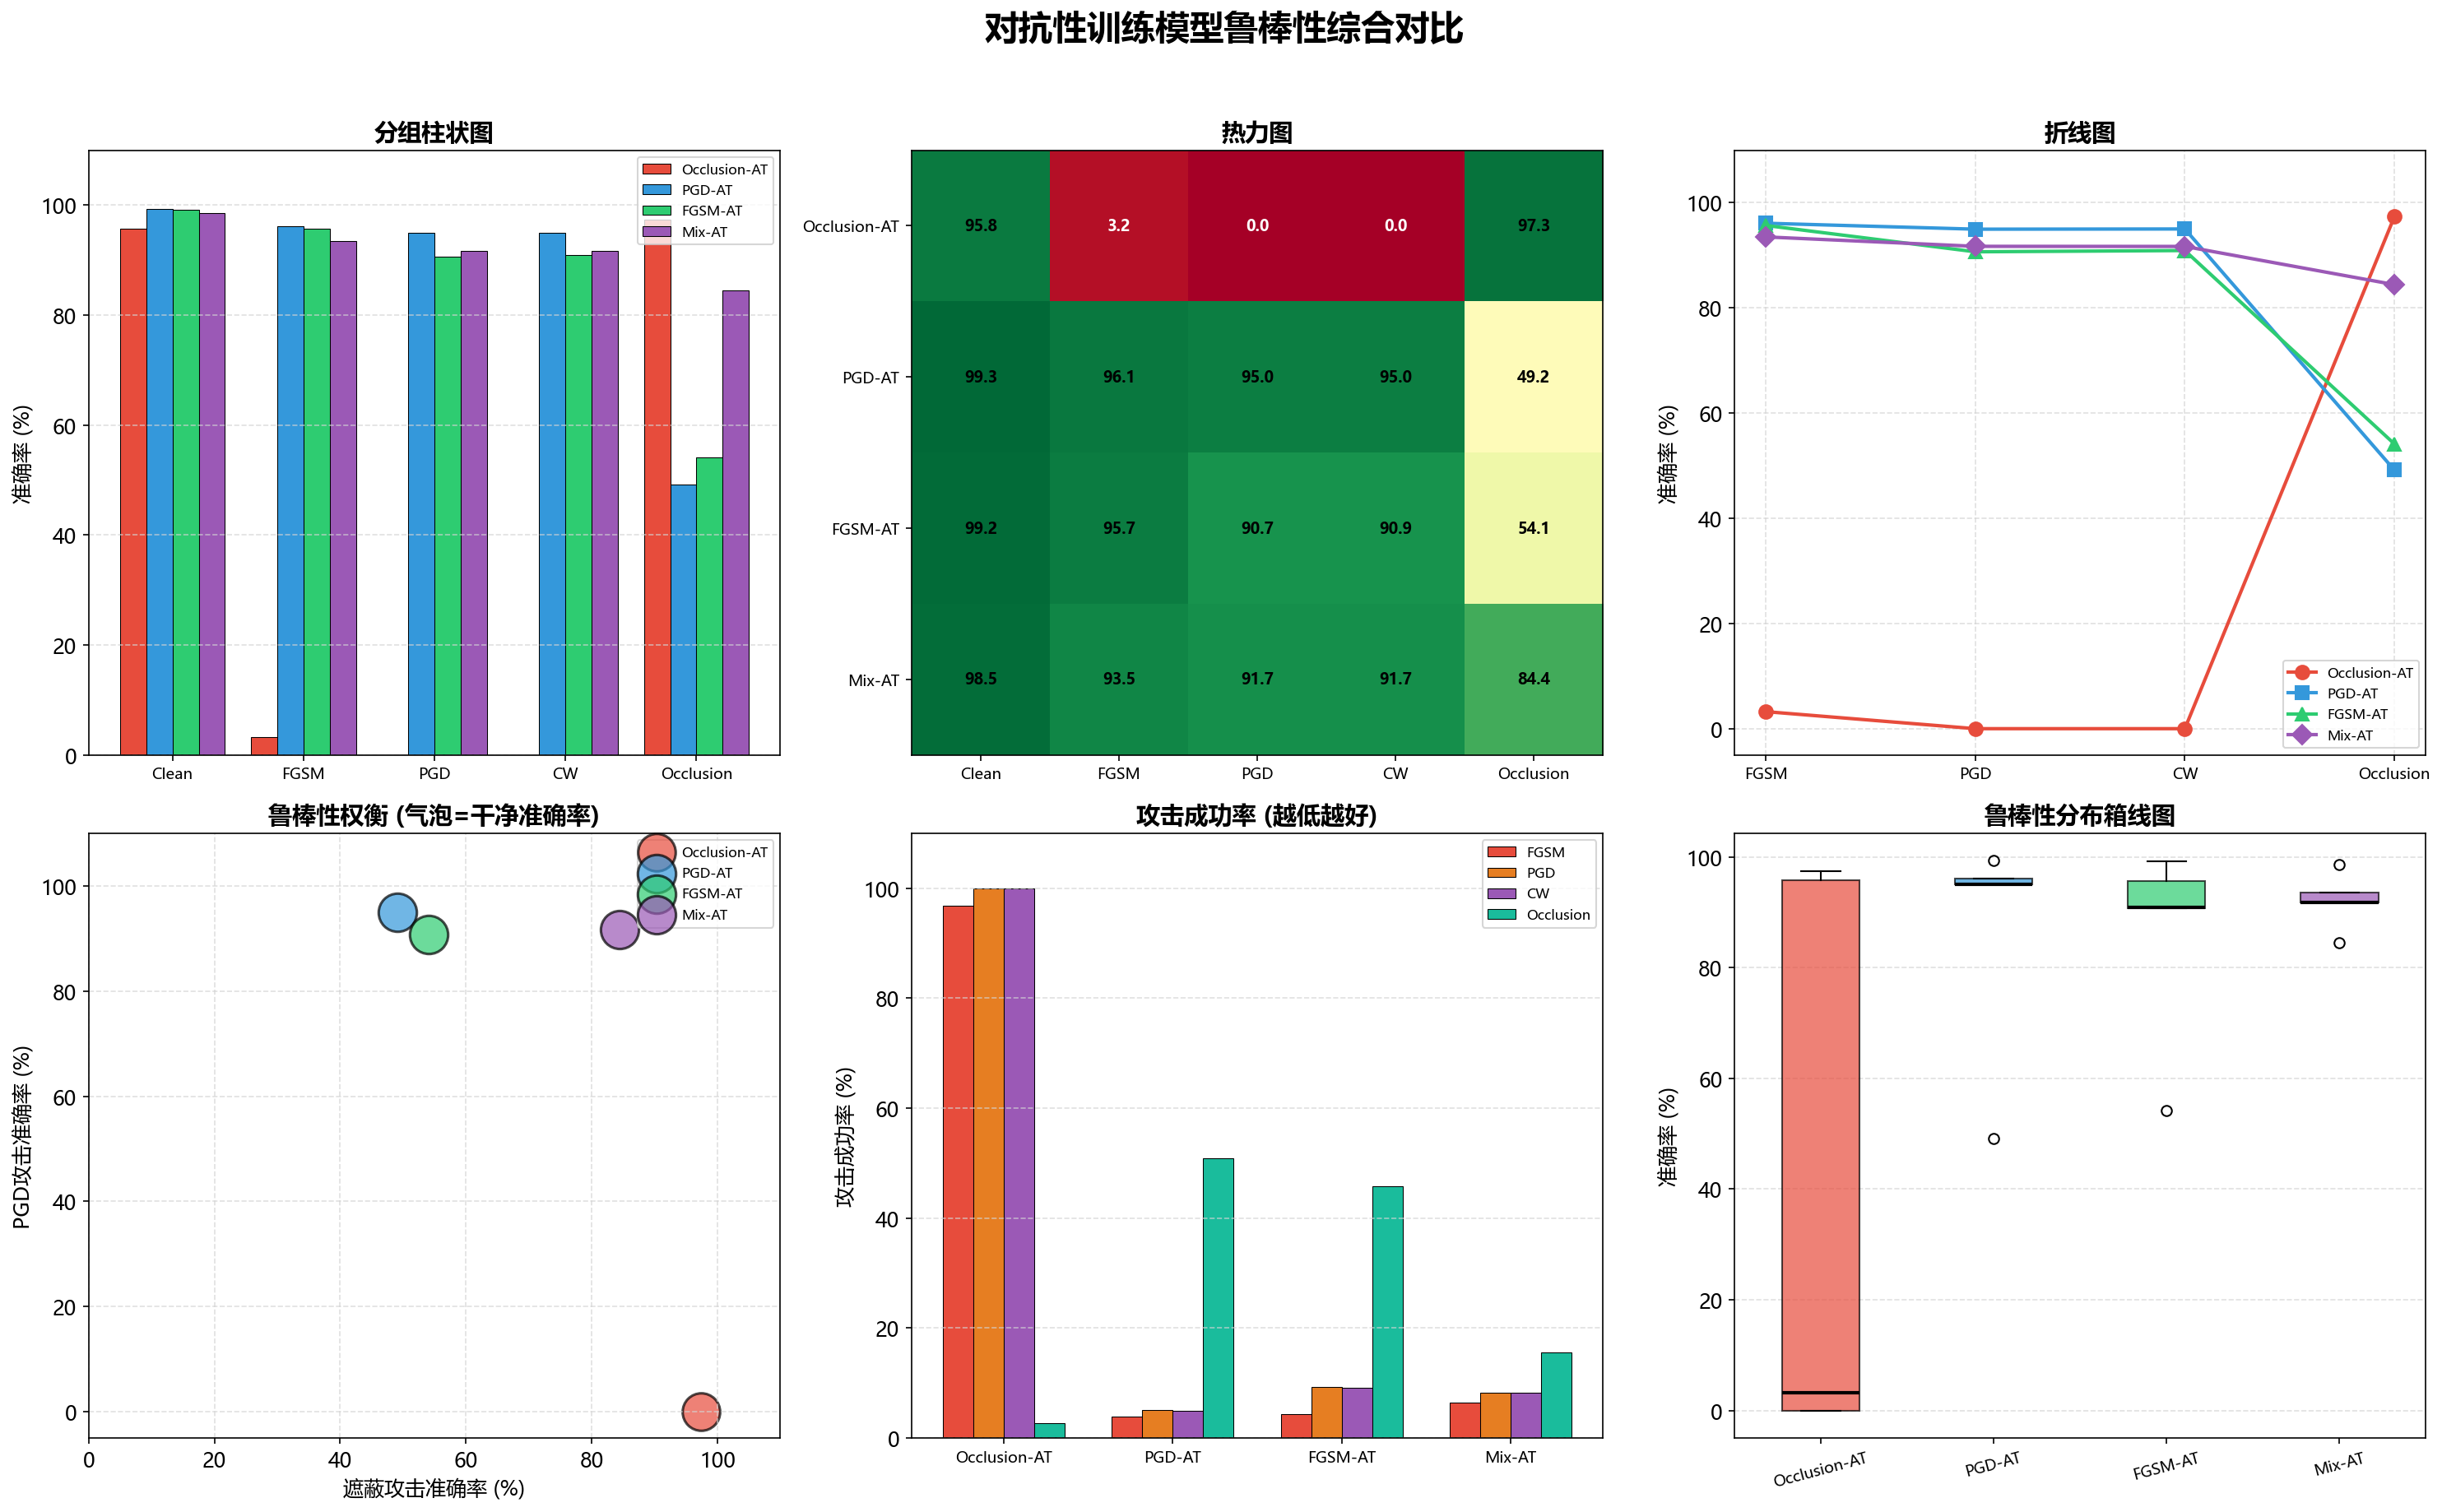

In [17]:
fig = plt.figure(figsize=(20, 12))

# 子图1: 分组柱状图
ax1 = fig.add_subplot(2, 3, 1)
x = np.arange(len(metrics))
width = 0.2
for i, model in enumerate(models):
    values = [results[model][m] for m in metrics]
    ax1.bar(x + i * width, values, width, label=model, color=colors[model],
           edgecolor='black', linewidth=0.5)
ax1.set_ylabel('准确率 (%)')
ax1.set_title('分组柱状图', fontweight='bold')
ax1.set_xticks(x + width * 1.5)
ax1.set_xticklabels(metrics, fontsize=9)
ax1.legend(fontsize=8)
ax1.set_ylim(0, 110)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# 子图2: 热力图
ax2 = fig.add_subplot(2, 3, 2)
data_array = np.array([[results[model][m] for m in metrics] for model in models])
im = ax2.imshow(data_array, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)
ax2.set_xticks(np.arange(len(metrics)))
ax2.set_yticks(np.arange(len(models)))
ax2.set_xticklabels(metrics, fontsize=9)
ax2.set_yticklabels(models, fontsize=9)
for i in range(len(models)):
    for j in range(len(metrics)):
        text_color = 'white' if data_array[i, j] < 30 else 'black'
        ax2.text(j, i, f'{data_array[i, j]:.1f}', ha="center", va="center",
                color=text_color, fontsize=9, fontweight='bold')
ax2.set_title('热力图', fontweight='bold')

# 子图3: 折线图
ax3 = fig.add_subplot(2, 3, 3)
attack_types = ['FGSM', 'PGD', 'CW', 'Occlusion']
x3 = np.arange(len(attack_types))
markers = ['o', 's', '^', 'D']
for i, model in enumerate(models):
    values = [results[model][a] for a in attack_types]
    ax3.plot(x3, values, marker=markers[i], linewidth=2, markersize=8,
            label=model, color=colors[model])
ax3.set_ylabel('准确率 (%)')
ax3.set_title('折线图', fontweight='bold')
ax3.set_xticks(x3)
ax3.set_xticklabels(attack_types, fontsize=9)
ax3.legend(fontsize=8)
ax3.set_ylim(-5, 110)
ax3.grid(True, linestyle='--', alpha=0.7)

# 子图4: 鲁棒性权衡
ax4 = fig.add_subplot(2, 3, 4)
for model in models:
    occ_acc = results[model]['Occlusion']
    pgd_acc = results[model]['PGD']
    clean_acc = results[model]['Clean']
    ax4.scatter(occ_acc, pgd_acc, s=clean_acc*5, c=colors[model],
               label=model, alpha=0.7, edgecolors='black', linewidth=1.5)
ax4.set_xlabel('遮蔽攻击准确率 (%)')
ax4.set_ylabel('PGD攻击准确率 (%)')
ax4.set_title('鲁棒性权衡 (气泡=干净准确率)', fontweight='bold')
ax4.legend(fontsize=8)
ax4.set_xlim(0, 110)
ax4.set_ylim(-5, 110)
ax4.grid(True, linestyle='--', alpha=0.7)

# 子图5: 攻击成功率
ax5 = fig.add_subplot(2, 3, 5)
x5 = np.arange(len(models))
width5 = 0.18
for i, attack in enumerate(attack_types):
    attack_rates = [100 - results[model][attack] for model in models]
    ax5.bar(x5 + i * width5, attack_rates, width5, label=attack, color=attack_colors[attack],
           edgecolor='black', linewidth=0.5)
ax5.set_ylabel('攻击成功率 (%)')
ax5.set_title('攻击成功率 (越低越好)', fontweight='bold')
ax5.set_xticks(x5 + width5 * 1.5)
ax5.set_xticklabels(models, fontsize=9)
ax5.legend(fontsize=8)
ax5.set_ylim(0, 110)
ax5.grid(axis='y', linestyle='--', alpha=0.7)

# 子图6: 箱线图
ax6 = fig.add_subplot(2, 3, 6)
data_box = [[results[model][m] for m in metrics] for model in models]
bp = ax6.boxplot(data_box, labels=models, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, model in zip(bp['boxes'], models):
    patch.set_facecolor(colors[model])
    patch.set_alpha(0.7)
ax6.set_ylabel('准确率 (%)')
ax6.set_title('鲁棒性分布箱线图', fontweight='bold')
ax6.grid(axis='y', linestyle='--', alpha=0.7)
ax6.set_xticklabels(models, fontsize=9, rotation=15)

fig.suptitle('对抗性训练模型鲁棒性综合对比', fontsize=20, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('./results_figures/fig15_comprehensive.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

In [18]:
print('所有图表已生成完成！')
print('保存位置: ./results_figures/')

所有图表已生成完成！
保存位置: ./results_figures/
